# River Flood Exposure Analysis

This notebook overlays **river flood depth data** onto Serbia's main road network to identify which road segments are exposed to flooding.

**Key steps:**
1. Load the country boundary and road network
2. Load and clip the flood hazard raster to Serbia
3. Assign flood depth to each road segment
4. Correct flood depths for road elevation bias (roads sit above terrain)
5. Visualise results and save as ArcGIS layers

> **Note:** The elevation correction is critical — without it, flood depths are overestimated because flood maps measure depth relative to terrain, but roads are typically elevated above the surrounding ground.

## Step 1: Setup and Imports

In [64]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

### Helper functions

In [65]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")


def assign_flood_depth_to_roads(roads, raster_data, raster_bounds, raster_crs):
    """Assign maximum flood depth from a raster to each road segment."""
    from rasterio.io import MemoryFile
    from rasterio.transform import from_bounds
    from rasterstats import zonal_stats

    FLOOD_BINS = [0, 1, 2, 3, 4, 5, np.inf]

    roads = roads.to_crs(raster_crs)
    rows, cols = raster_data.shape
    left, bottom, right, top = raster_bounds
    raster_transform = from_bounds(left, bottom, right, top, cols, rows)

    with MemoryFile() as memfile:
        with memfile.open(
            driver="GTiff", height=rows, width=cols,
            count=1, dtype=raster_data.dtype,
            crs=raster_crs, transform=raster_transform,
        ) as dataset:
            dataset.write(raster_data, 1)

        stats = zonal_stats(
            roads, memfile.name,
            stats=["max"], nodata=np.nan, all_touched=True,
        )

    roads["flood_depth_max"] = [s["max"] for s in stats]

    bin_labels = [f"{lo}\u2013{hi}m" if hi != np.inf else "5m+"
                  for lo, hi in zip(FLOOD_BINS[:-1], FLOOD_BINS[1:])]
    roads["flood_class"] = pd.cut(
        roads["flood_depth_max"], bins=FLOOD_BINS,
        labels=bin_labels, include_lowest=True,
    ).astype(str)
    roads["flood_class"] = roads["flood_class"].where(
        roads["flood_depth_max"].notna() & (roads["flood_depth_max"] > 0),
        other="No flooding",
    )

    n_flooded = (roads["flood_class"] != "No flooding").sum()
    print(f"Roads with flood depth assigned : {n_flooded:,}")
    print(f"Roads with no flooding          : {(roads['flood_class'] == 'No flooding').sum():,}")
    print(f"Flood depth range               : {roads['flood_depth_max'].min():.2f} \u2013 {roads['flood_depth_max'].max():.2f} m")

    return roads

### Define file paths

All input data, intermediate results, and outputs are organised under a single project directory.

In [68]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Create output directories if they don't exist
figure_path.mkdir(parents=True, exist_ok=True)
arcgis_results.mkdir(parents=True, exist_ok=True)
arcgis_gpkg.mkdir(parents=True, exist_ok=True)

## Step 2: Load Data

### Country boundary and road network

In [69]:
# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_bounds = world.loc[world.SOV_A3 == 'SRB'].bounds
country_plot = world.loc[world.SOV_A3 == 'SRB']

# Load road network
roads = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")

# Clip to Serbia only (remove Kosovo roads)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))


print(f"Road segments loaded: {len(roads):,}")
print(f"CRS: {roads.crs}")

Road segments loaded: 1,828
CRS: EPSG:4326


### Load and clip the flood hazard raster

We use a **100-year return period** fluvial flood depth map and clip it to Serbia's bounding box.

In [70]:
fluvial_flooding_path = data_path / "Europe_RP100_filled_depth.tif"

hazard_map = xr.open_dataset(fluvial_flooding_path, engine="rasterio")
hazard_country = hazard_map.rio.clip_box(
    minx=country_bounds.minx.values[0],
    miny=country_bounds.miny.values[0],
    maxx=country_bounds.maxx.values[0],
    maxy=country_bounds.maxy.values[0]
).load()

print(f"Raster shape: {hazard_country.band_data.shape}")
print(f"Raster CRS: {hazard_country.rio.crs}")

Raster shape: (1, 4728, 4968)
Raster CRS: EPSG:4326


## Step 3: Visualise the Flood Hazard Map

Before overlaying on roads, let's look at the raw flood depth across Serbia.

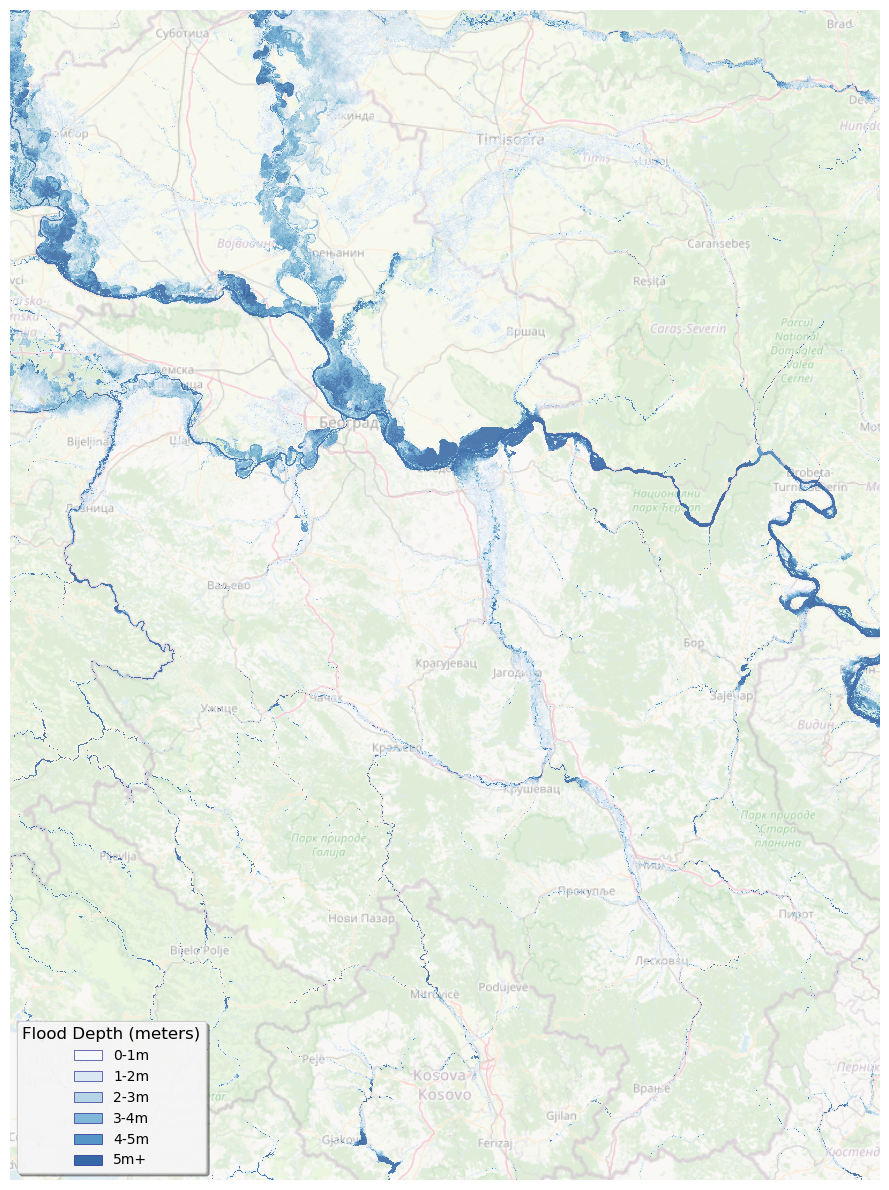

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

# Blue flood depth colormap
flood_colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']
flood_cmap = LinearSegmentedColormap.from_list('flood_blue', flood_colors, N=256)

# Reproject to Web Mercator for basemap overlay
if hazard_country.rio.crs is None:
    hazard_country = hazard_country.rio.write_crs("EPSG:4326")
hazard_mercator = hazard_country.rio.reproject("EPSG:3857")

# Plot raster
hazard_mercator.band_data.plot(
    ax=ax, cmap=flood_cmap, alpha=0.7,
    vmin=0, vmax=6,
    add_colorbar=False, add_labels=False,
)

cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.4, attribution=False)
ax.axis('off')

# Legend
flood_labels = ['0-1m', '1-2m', '2-3m', '3-4m', '4-5m', '5m+']
legend_colors = [flood_cmap(i / 5) for i in range(6)]
legend_elements = [Patch(facecolor=legend_colors[i], label=flood_labels[i],
                         edgecolor='navy', linewidth=0.5, alpha=0.8)
                   for i in range(len(flood_labels))]
ax.legend(handles=legend_elements, title='Flood Depth (meters)',
          loc='lower left', fontsize=10, title_fontsize=12,
          frameon=True, fancybox=True, shadow=True, framealpha=0.9,
          facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()

## Step 4: Overlay Flood Depth onto Roads

We assign the maximum flood depth from the raster to each road segment using zonal statistics.

In [72]:
roads = assign_flood_depth_to_roads(
    roads=roads,
    raster_data=hazard_country.band_data.values.squeeze(),
    raster_bounds=hazard_country.rio.bounds(),
    raster_crs=hazard_country.rio.crs,
)

# Simplify to flooded / not flooded
roads["flood_class"] = roads["flood_class"].apply(
    lambda x: "No flooding" if x == "No flooding" else "Flooded"
)

print(f"\nFlooded segments: {(roads['flood_class'] == 'Flooded').sum():,}")
print(f"Not flooded: {(roads['flood_class'] == 'No flooding').sum():,}")

Roads with flood depth assigned : 953
Roads with no flooding          : 875
Flood depth range               : 0.10 – 54.62 m

Flooded segments: 953
Not flooded: 875


### Visualise raw flood exposure on roads (before correction)

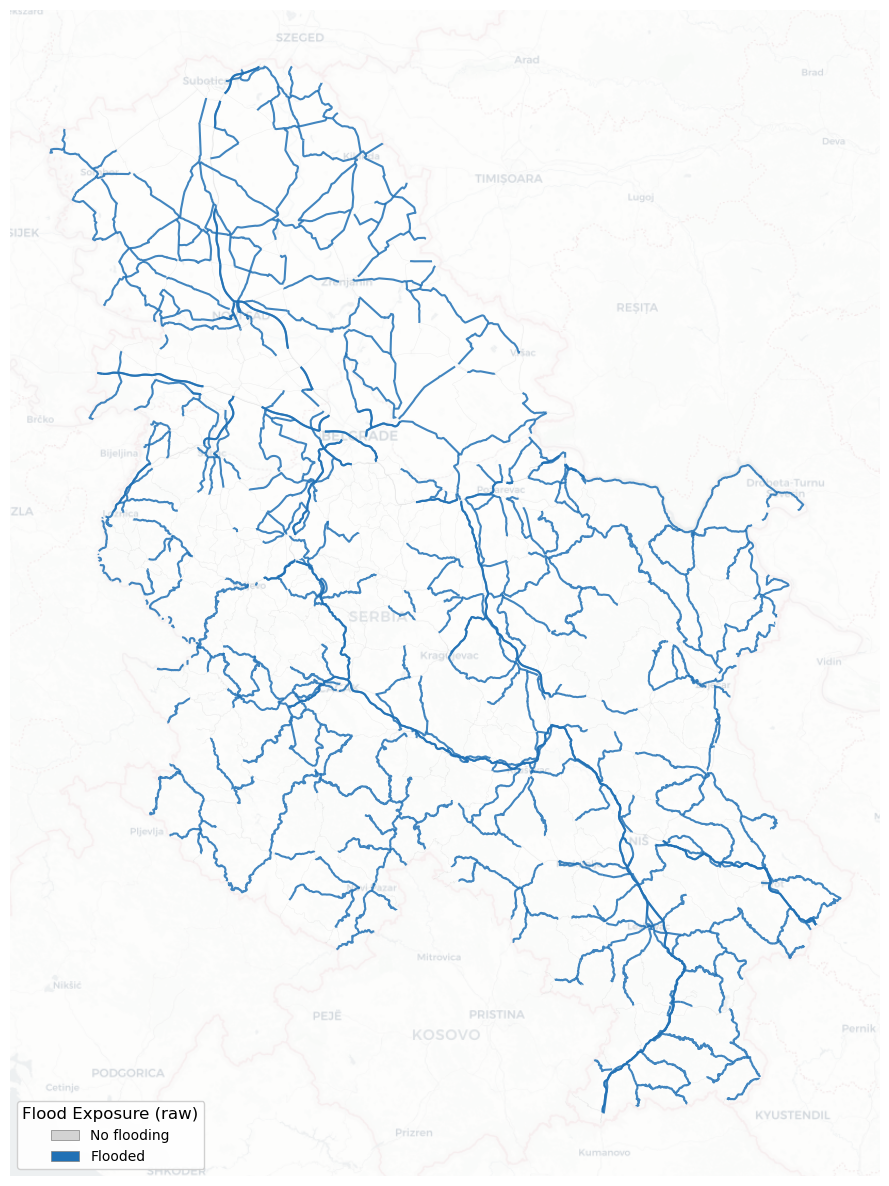

In [73]:
original_crs = roads.crs
roads_plot = roads.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor="white")

# Not flooded (grey)
roads_plot[roads_plot["flood_class"] == "No flooding"].plot(
    ax=ax, color="#d3d3d3", linewidth=0.3, alpha=0.4, zorder=1
)

# Flooded (blue)
roads_plot[roads_plot["flood_class"] != "No flooding"].plot(
    ax=ax, color="#2171b5", linewidth=1.5, alpha=0.85, zorder=2
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
ax.axis("off")

legend_handles = [
    Patch(facecolor="#d3d3d3", label="No flooding", edgecolor="grey", linewidth=0.5),
    Patch(facecolor="#2171b5", label="Flooded", edgecolor="grey", linewidth=0.5),
]
ax.legend(handles=legend_handles, title="Flood Exposure (raw)", loc="lower left",
          fontsize=10, title_fontsize=12, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

## Step 5: Elevation Bias Correction

### Why correct?

Flood hazard maps report water depth **relative to the terrain surface** (DEM). However, roads — especially highways and major routes — are typically built **above** the surrounding terrain on embankments.

A pre-analysis compared measured road elevations (from Z-coordinates in the Serbian road database) against the DEM and found a consistent **positive bias**: roads sit higher than the DEM suggests.

| Road Category | Elevation Bias (meters) | Description |
|:---|:---|:---|
| **IA** (Motorways) | 4.60 m | Highest — built on large embankments |
| **IM** (Urban motorways) | 3.66 m | Also elevated, urban context |
| **IB** (Express roads) | 0.82 m | Moderate embankment |
| **IIA** (Main roads) | 0.82 m | Moderate embankment |
| **IIB** (Regional roads) | 0.82 m | Moderate embankment |

Without this correction, we would significantly overestimate how many road segments are flooded.

### Fix missing road categories

Some road segments have missing category labels — we fill them based on the road designation code.

In [74]:
cat_map = {
    'A1': 'IA',
    'A2': 'IA',
    'A3': 'IA',
    'A4': 'IA',
    '39': 'IB'
}

mask = roads['kategorija'].isna()
roads.loc[mask, 'kategorija'] = roads.loc[mask, 'oznaka_put'].map(cat_map)

print(f"Fixed {mask.sum()} segments with missing categories")
print(f"Category distribution:\n{roads['kategorija'].value_counts()}")

Fixed 0 segments with missing categories
Category distribution:
kategorija
IIA    715
IB     545
IIB    272
IA     220
IM      76
Name: count, dtype: int64


### Apply the elevation bias correction

We subtract the category-specific bias from the raw flood depth. Any resulting negative values (meaning the road is higher than the flood) are clipped to zero.

In [75]:
# Pre-computed elevation bias per road category (meters)
elevation_bias = {
    'IA': 4.601,
    'IM': 3.659,
    'IB': 0.82,
    'IIA': 0.82,
    'IIB': 0.82
}

# Apply correction
roads['bias'] = roads['kategorija'].map(elevation_bias)
roads['corrected_flood_depth'] = (roads['flood_depth_max'] - roads['bias']).clip(lower=0)

# Update flood class based on corrected depth
roads['flood_class_corrected'] = np.where(
    roads['corrected_flood_depth'] > 0, "Flooded", "No flooding"
)

# Summary
summary = roads.groupby('kategorija').agg(
    total=('flood_depth_max', 'count'),
    originally_flooded=('flood_depth_max', lambda x: (x > 0).sum()),
    still_flooded=('corrected_flood_depth', lambda x: (x > 0).sum()),
    bias=('bias', 'first'),
    avg_original_depth=('flood_depth_max', 'mean'),
    avg_corrected_depth=('corrected_flood_depth', 'mean')
).reset_index()
summary['removed'] = summary['originally_flooded'] - summary['still_flooded']
summary['pct_removed'] = (summary['removed'] / summary['originally_flooded'] * 100).round(1)

print(summary.to_string(index=False))

kategorija  total  originally_flooded  still_flooded  bias  avg_original_depth  avg_corrected_depth  removed  pct_removed
        IA    161                 161             58 4.601            4.017534             0.852838      103         64.0
        IB    288                 288            268 0.820            5.159622             4.355597       20          6.9
       IIA    365                 365            323 0.820            4.179285             3.396096       42         11.5
       IIB     98                  98             86 0.820            3.733357             2.953378       12         12.2
        IM     41                  41             19 3.659            4.216244             1.473122       22         53.7


## Step 6: Before vs After Correction

Side-by-side comparison showing how many flood-exposed roads are removed after accounting for road elevation.

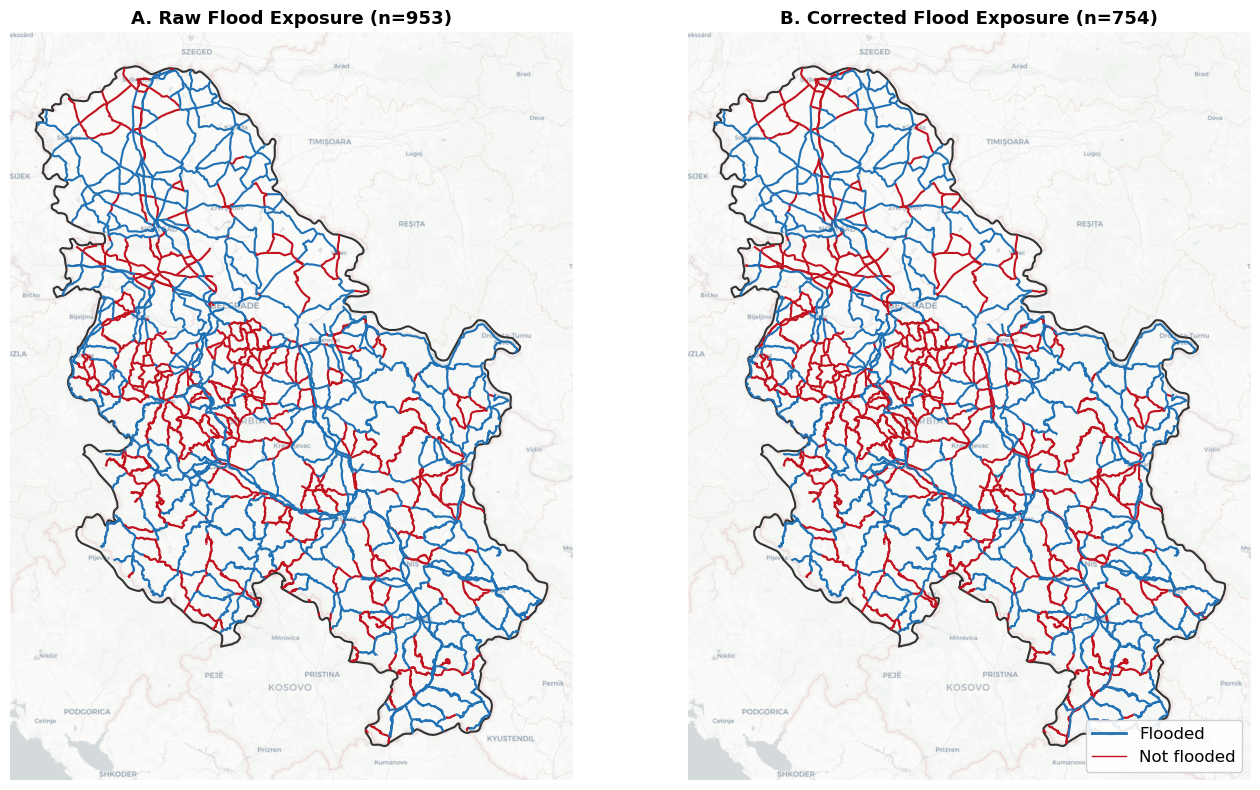


Raw flooded segments:       953
Corrected flooded segments: 754
Segments removed:           199


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

for idx, (label, depth_col, class_col, title) in enumerate([
    ('A', 'flood_depth_max', 'flood_class', 'Raw Flood Exposure'),
    ('B', 'corrected_flood_depth', 'flood_class_corrected', 'Corrected Flood Exposure'),
]):
    ax = axes[idx]

    # Country outline
    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                         linewidth=1.5, zorder=1)

    # Not flooded (red)
    not_flooded = roads_mercator[roads_mercator[class_col] == "No flooding"]
    if not not_flooded.empty:
        not_flooded.plot(ax=ax, color='#c1121f', linewidth=1.5, zorder=2)

    # Flooded (blue)
    flooded = roads_mercator[roads_mercator[class_col] != "No flooding"]
    if not flooded.empty:
        flooded.plot(ax=ax, color='#2171b5', linewidth=1.5, zorder=3)

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
    ax.set_aspect('equal')
    ax.axis('off')

    # Panel label
    n_flooded = (roads[class_col] != "No flooding").sum()
    ax.set_title(f"{label}. {title} (n={n_flooded:,})", fontsize=13, fontweight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], color='#2171b5', lw=2, label='Flooded'),
    Line2D([0], [0], color='#c1121f', lw=1, label='Not flooded'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12,
               frameon=True, fancybox=True, framealpha=0.9,
               facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'flood_exposure_correction.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRaw flooded segments:       {(roads['flood_class'] != 'No flooding').sum():,}")
print(f"Corrected flooded segments: {(roads['flood_class_corrected'] != 'No flooding').sum():,}")
print(f"Segments removed:           {(roads['flood_class'] != 'No flooding').sum() - (roads['flood_class_corrected'] != 'No flooding').sum():,}")

## Step 7: Save Results as ArcGIS Layers

The results are saved as:
- **GeoPackage** (.gpkg) — the data, viewable in any GIS software
- **Layer file** (.lyrx) — pre-styled for ArcGIS Pro with correct symbology

After running this cell, open the `.lyrx` file in ArcGIS Pro to see the flood exposure on your map.

In [77]:
save_lyrx_layer(
    gdf=roads.to_crs(original_crs),
    gpkg_path=arcgis_gpkg / "flood_depth_roads.gpkg",
    lyrx_path=arcgis_results / "flood_depth_roads.lyrx",
    layer_name="flood_depth_roads",
    labels=["No flooding", "Flooded"],
    colors=["#d3d3d3", "#2171b5"],
    width_mapping={"No flooding": 0.3, "Flooded": 1.5},
    field="flood_class_corrected",
    title="Flood Depth on Roads (Corrected)",
)

print("\n✅ Done! Open 'flood_depth_roads.lyrx' in ArcGIS Pro to view the results.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\flood_depth_roads.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\flood_depth_roads.lyrx

✅ Done! Open 'flood_depth_roads.lyrx' in ArcGIS Pro to view the results.


---

## Part 2: Future Flood Risk Under Climate Change

In this section we assess how **climate change affects flood return periods**. A flood that currently has a 100-year return period may become much more frequent under warming scenarios.

We use ensemble flood projections at four warming levels (1.5°C, 2.0°C, 3.0°C, 4.0°C) aggregated to river basins, then assign the results to road segments.

**Additional imports and data needed:**

In [78]:
import string
import xarray as xr
import rioxarray
import matplotlib.patches as mpatches

### Define warming scenarios and classification bins

The bins represent the *new* return period of what is currently a 100-year flood. Lower values = more frequent = more dangerous.

In [79]:
scenarios = ["15", "20", "30", "40"]
scenario_labels = {"15": "1.5", "20": "2.0", "30": "3.0", "40": "4.0"}

# Return period bins (years)
rp_bins = [10, 25, 50, 100, 150, np.inf]
rp_labels = ["10-25", "25-50", "50-100", "100-150", "150+"]
rp_colors = ["#b2182b", "#ef8a62", "#fddbc7", "#d1e5f0", "#67a9cf"]
rp_color_dict = dict(zip(rp_labels, rp_colors))
rp_color_dict["No data"] = "white" 

### Load basin data and climate projections

In [88]:
# Load pre-computed flood statistics per basin
basins_csv = pd.read_csv(data_path / "SRB_flood_statistics_per_Basin_basins_scenario.csv")

# Load basin geometries
all_basins = gpd.read_file(data_path / "hybas_eu_lev09_v1c.shp")
basins = gpd.GeoDataFrame(basins_csv.merge(all_basins, left_on='basinID', right_on='HYBAS_ID'))

# Open climate ensemble NetCDF
ds = xr.open_dataset(data_path / "disEnsemble_highExtremes.nc")
ds = ds.rio.write_crs("EPSG:3035", inplace=False)

# Prepare return period shift data for all scenarios
rl_dict = {}
for scenario in scenarios:
    rp = ds[f"baseline_rp_shift_{scenario}"]
    rp = rp.transpose("y", "x").sortby("y")
    rp = rp.rio.write_crs("EPSG:3035", inplace=False)
    rp = rp.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
    rl_dict[f"rp_shift_{scenario}"] = rp

print(f"Basins loaded: {len(basins):,}")
print(f"Scenarios: {', '.join(scenario_labels[s] + '°C' for s in scenarios)}")

Basins loaded: 301
Scenarios: 1.5°C, 2.0°C, 3.0°C, 4.0°C


### Calculate mean return period shift per basin

For each warming scenario, we clip the raster to each basin and compute the mean new return period.

In [ ]:
basins_3035 = basins.to_crs(rl_dict["rp_shift_30"].rio.crs)

for scenario in scenarios:
    print(f"Processing {scenario_labels[scenario]}°C...")
    da = rl_dict[f"rp_shift_{scenario}"]

    mean_vals = []
    for _, basin in basins_3035.iterrows():
        masked = da.rio.clip([basin.geometry], basins_3035.crs, drop=False)
        vals = masked.values[~np.isnan(masked.values)]
        mean_vals.append(vals.mean() if vals.size else np.nan)

    basins_3035[f"rp{scenario}_mean"] = mean_vals
    print(f"  Range: {np.nanmin(mean_vals):.1f} – {np.nanmax(mean_vals):.1f} years")

### Assign future flood return periods to roads

We spatially join roads to basins, so each road inherits the return period shift from its basin.

In [ ]:
# Ensure roads are in EPSG:3035
roads_future = roads.to_crs("EPSG:3035")

# Clean up columns
for col in ["index_right", "index_left"]:
    roads_future = roads_future.drop(columns=[col], errors="ignore")
    basins_3035 = basins_3035.drop(columns=[col], errors="ignore")

# Spatial join: roads → basins
roads_rp = gpd.sjoin(
    roads_future,
    basins_3035[["geometry"] + [f"rp{s}_mean" for s in scenarios]],
    how="left", predicate="intersects"
)

# Bin each scenario
for scenario in scenarios:
    roads_rp[f"rp{scenario}_bin"] = pd.cut(
        roads_rp[f"rp{scenario}_mean"],
        bins=rp_bins, labels=rp_labels, include_lowest=True
    )

print(f"Roads with future flood data: {roads_rp[f'rp30_mean'].notna().sum():,}")

### Visualise: Future return periods by basin (2×2)

In [ ]:
basins_3857 = basins_3035.to_crs(3857)

fig, axes = plt.subplots(2, 2, figsize=(10, 14.5))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    col_mean = f"rp{scenario}_mean"
    basins_3857[f"rp{scenario}_bin"] = pd.cut(
        basins_3857[col_mean], bins=rp_bins, labels=rp_labels, include_lowest=True
    )

    plot_col = basins_3857[f"rp{scenario}_bin"].astype(str)
    plot_col = plot_col.replace("nan", "No data")
    basins_3857[f"plot_color_{scenario}"] = plot_col.map(rp_color_dict)

    basins_3857.plot(color=basins_3857[f"plot_color_{scenario}"],
                     edgecolor="black", linewidth=0.5, ax=axes_flat[i])
    cx.add_basemap(ax=axes_flat[i], source=cx.providers.CartoDB.Positron,
                   alpha=1.0, attribution=False)
    axes_flat[i].set_title(f"Warming: {scenario_labels[scenario]}°C", fontsize=14)
    axes_flat[i].set_axis_off()

# Legend
handles = [mpatches.Patch(facecolor=rp_color_dict[l], edgecolor="black", label=l)
           for l in rp_labels + ["No data"]]
fig.legend(handles=handles,
           title="New return period of current 100-year flood (years)",
           loc="lower center", ncol=len(handles),
           frameon=True, edgecolor="black", facecolor="white")

# Panel labels
axes_sorted = sorted(axes_flat[:4],
                     key=lambda ax: (-ax.get_position().y0, ax.get_position().x0))
for i, ax in enumerate(axes_sorted):
    ax.text(0.05, 0.95, string.ascii_uppercase[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(figure_path / 'future_flood_return_periods_basins.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualise: Future return periods on roads (2×2)

In [ ]:
roads_rp_3857 = roads_rp.to_crs(3857)
roads_bg = roads_future.to_crs(3857)

fig, axes = plt.subplots(2, 2, figsize=(10, 14.5))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]

    plot_col = roads_rp_3857[f"rp{scenario}_bin"].astype(str)
    plot_col = plot_col.replace("nan", "No data")
    roads_rp_3857[f"plot_color_{scenario}"] = plot_col.map(rp_color_dict)

    roads_bg.plot(ax=ax, color="grey", linewidth=0.8)
    roads_rp_3857.plot(color=roads_rp_3857[f"plot_color_{scenario}"],
                       edgecolor="black", linewidth=1.2, ax=ax)

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
                   alpha=1.0, attribution=False)
    ax.set_title(f"Warming: {scenario_labels[scenario]}°C", fontsize=14)
    ax.set_axis_off()

# Legend
legend_handles = [mpatches.Patch(facecolor=rp_color_dict[l], edgecolor="black", label=l)
                  for l in rp_labels]
fig.legend(handles=legend_handles,
           title="New return period of current 100-year flood (years)",
           loc="lower center", ncol=len(legend_handles),
           frameon=True, edgecolor="black", facecolor="white")

axes_sorted = sorted(axes_flat[:4],
                     key=lambda ax: (-ax.get_position().y0, ax.get_position().x0))
for i, ax in enumerate(axes_sorted):
    ax.text(0.05, 0.95, string.ascii_uppercase[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(figure_path / 'future_flood_return_periods_roads.png', dpi=300, bbox_inches='tight')
plt.show()

### Save future flood results as ArcGIS layers

We save the **3.0°C warming scenario** as the primary output — a commonly used planning scenario.

In [ ]:
# Use 3.0°C scenario for ArcGIS output
roads_rp["future_flood_class"] = roads_rp["rp30_bin"].astype(str).replace("nan", "No data")

# Drop categorical columns that fiona can't serialize
cat_cols = [c for c in roads_rp.columns if roads_rp[c].dtype.name == 'category']
roads_export = roads_rp.drop(columns=cat_cols)

output_labels = ["No data"] + rp_labels
output_colors = ["#d3d3d3"] + rp_colors

save_lyrx_layer(
    gdf=roads_export.to_crs(original_crs),
    gpkg_path=arcgis_gpkg / "future_flood_return_periods.gpkg",
    lyrx_path=arcgis_results / "future_flood_return_periods.lyrx",
    layer_name="future_flood_return_periods",
    labels=output_labels,
    colors=output_colors,
    width_mapping={label: 1.2 for label in output_labels},
    field="future_flood_class",
    title="Future Flood Return Periods (3.0°C warming)",
)

print("\n✅ Open 'future_flood_return_periods.lyrx' in ArcGIS Pro to view the results.")